In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
units = np.load('../Data/units.npy',allow_pickle=True)
subj  = np.load('../Data/subjs_sep.npy',allow_pickle=True)
subj  = [s[0] for s in subj]

uniqueSub = np.unique(subj)
for s in uniqueSub:
    m = np.where(subj==s)[0]
    neurons = [len(units[mi][0]) for mi in m]
    print('Sub ',s,': ' ,np.sum(neurons),'neurons, ',len(neurons),'recordings'#,[units[mi][0] for mi in m]
         )

Sub  40 :  98 neurons,  7 recordings
Sub  43 :  133 neurons,  2 recordings
Sub  44 :  161 neurons,  3 recordings
Sub  45 :  27 neurons,  2 recordings
Sub  47 :  40 neurons,  2 recordings
Sub  53 :  119 neurons,  4 recordings
Sub  57 :  59 neurons,  3 recordings
Sub  58 :  175 neurons,  4 recordings
Sub  61 :  79 neurons,  3 recordings
Sub  63 :  60 neurons,  2 recordings
Sub  64 :  45 neurons,  3 recordings


In [4]:
HYP = 0
AMY = 0
ENT = 0

for i in range(len(units)):
    u = units[i][0]
    for ui in u:
        if('AH' in ui or 'PH' in ui):
            HYP += 1
        elif('AL' in ui or 'AR' in ui):
            AMY += 1
        else:
            ENT += 1

In [5]:
n = HYP+AMY+ENT
print(n)
print(HYP,HYP/n)
print(AMY,AMY/n)
print(ENT,ENT/n)

996
559 0.5612449799196787
239 0.2399598393574297
198 0.19879518072289157


In [6]:
L = 0
R = 0

for i in range(len(units)):
    u = units[i][0]
    for ui in u:
        if('R' in ui):
            R += 1
        elif('L' in ui ):
            L += 1

print(L)
print(R)

555
441


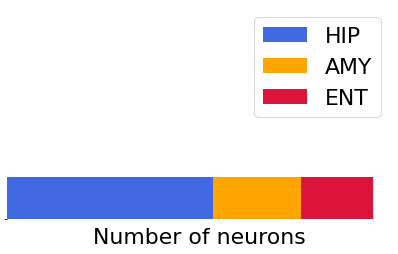

In [8]:
plt.rcParams.update({'font.size': 22})

# Data for the plot
labels   = ['']
HYP_vals = [HYP]
AMY_vals = [AMY]
ENT_vals = [ENT]

# Create stacked horizontal bar plot
fig, ax = plt.subplots()
ax.barh(labels, HYP_vals, label='HIP', color='royalblue')
ax.barh(labels, AMY_vals, left=HYP_vals, label='AMY', color='orange')
ax.barh(labels, ENT_vals, left=[HYP + AMY], label='ENT', color='crimson')

# Remove spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.set_xticks([])
# Add labels and legend
plt.legend()
plt.ylim(0,2)  # Adjust as needed
plt.xlabel('Number of neurons')
plt.tight_layout()
plt.savefig('./units2.svg',dpi=200)
plt.show()

In [9]:
# reaction time
reaction = np.load('../Data/reaction.npy',allow_pickle=True)
letters  = np.load('../Data/letters_sep.npy',allow_pickle=True)
probes   = np.load('../Data/probes_sep.npy',allow_pickle=True)
info     = np.load('../Data/trial_corrInfo.npy',allow_pickle=True)
uniqueLetters = np.array([p for p in np.unique(np.concatenate(letters)) if p not in ['Q', 'W', 'X']])
print(uniqueLetters)

setsize  = [np.array([np.sum([1 if u in letterString else 0 for u in uniqueLetters]) for letterString in ls],dtype=int)
            for ls in letters]

['B' 'C' 'D' 'F' 'G' 'H' 'K' 'L' 'N' 'P' 'R' 'S' 'T' 'V' 'Z']


Primacy: chi2 = 8.602, p = 0.856


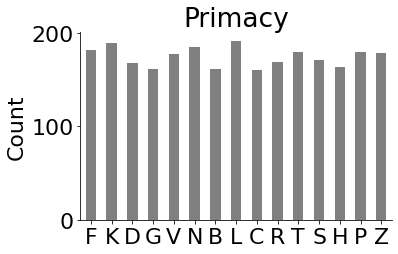

Recency: chi2 = 19.750, p = 0.138


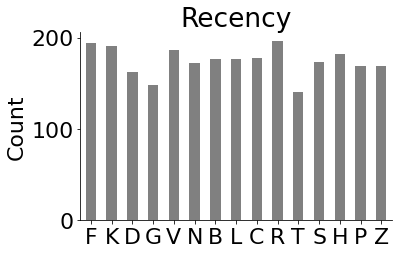

Letter count: chi2 = 13.000, p = 0.527


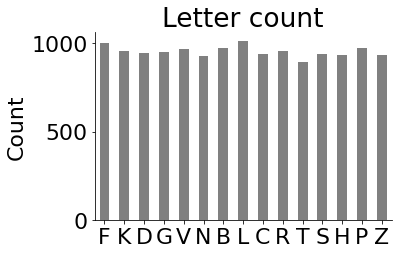

(13.0, 0.5265236225179997)

In [10]:
import numpy as np
from collections import Counter
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import chisquare

setLETTER = ['F','K','D','G','V','N','B','L','C','R','T','S','H','P','Z']

# flatten and remove unwanted letters
allL = np.concatenate(letters, axis=0)
allL = [[si for si in s if si not in ['X','Q','W']] for s in allL]

def plot_counts_with_test(items, title, filename):
    # count occurrences
    counts = Counter(items)
    observed = np.array([counts.get(k, 0) for k in setLETTER], dtype=float)
    total = observed.sum()

    if total > 0:
        # uniform expected counts
        expected = np.full_like(observed, total / len(setLETTER), dtype=float)

        # chi-square test against uniform
        chi2, p = chisquare(f_obs=observed, f_exp=expected)
        print(f"{title}: chi2 = {chi2:.3f}, p = {p:.3g}")
    else:
        chi2, p = np.nan, np.nan
        print(f"{title}: no data (all counts zero)")

    # DataFrame for plotting
    df = pd.DataFrame({'count': observed}, index=setLETTER)

    # Make and save bar plot
    fig, ax = plt.subplots()
    df.plot.bar(ax=ax, legend=False,color='gray')

    # remove top & right spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    ax.set_title(title)
    #ax.set_xlabel("Letter")
    ax.set_xticks(np.arange(15),setLETTER,rotation=0)
    ax.set_ylabel("Count")

    fig.tight_layout()
    fig.savefig(filename, dpi=300, bbox_inches='tight')
    plt.show()
    #plt.close(fig)

    return chi2, p

# First letters
first = [s[0] for s in allL if len(s) > 0]
plot_counts_with_test(first, "Primacy", "primacy.svg")

# Last letters
last = [s[-1] for s in allL if len(s) > 0]
plot_counts_with_test(last, "Recency", "recency.svg")

# All letters (any position)
all_letters_flat = [ch for s in allL for ch in s]
plot_counts_with_test(all_letters_flat, "Letter count", "letter_count.svg")

In [8]:
m4 = []
m6 = []
m8 = []

m4all = []
m6all = []
m8all = []
for s in np.unique(subj):
    mask  = np.where(subj==s)[0]
    lenS  = np.concatenate(np.array(setsize,dtype=object)[mask])
    respS = np.concatenate(np.array(reaction,dtype=object)[mask])
    
    m4.append(np.mean(respS[lenS==4]))
    m6.append(np.mean(respS[lenS==6]))
    m8.append(np.mean(respS[lenS==8]))
    
    m4all.extend(respS[lenS==4])
    m6all.extend(respS[lenS==6])
    m8all.extend(respS[lenS==8])

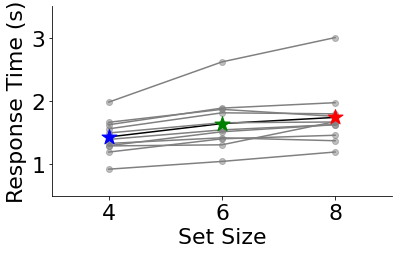

In [9]:
fig,ax = plt.subplots(figsize=(6,4))
plt.scatter([0]*len(m4),m4,color='gray',alpha=0.5,)
plt.scatter([0],np.mean(m4),color='blue',marker='*',s=250)
plt.scatter([1]*len(m6),m6,color='gray',alpha=0.5)
plt.scatter([1],np.mean(m6),color='green',marker='*',s=250)
plt.scatter([2]*len(m8),m8,color='gray',alpha=0.5)
plt.scatter([2],np.mean(m8),color='red',marker='*',s=250)
plt.plot([0,1,2],[np.mean(m4),np.mean(m6),np.mean(m8)],color='k',zorder=-1)
for i in range(len(m4)):
    plt.plot([0,1,2],[m4[i],m6[i],m8[i]],color='gray',zorder=-1)
plt.xlabel('Set Size')
plt.ylabel('Response Time (s)')
plt.xticks([0,1,2],[4,6,8])
plt.xlim(-0.5,2.5)
plt.ylim(0.5,3.5)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('./react.svg',dpi=200)
plt.show()

In [12]:
import pandas as pd
import pingouin as pg

# Organize into DataFrame
data = pd.DataFrame({
    'subject': np.arange(len(m4)),
    'm4': m4,
    'm6': m6,
    'm8': m8
})

# Melt to long format
df_long = data.melt(id_vars='subject', value_vars=['m4', 'm6', 'm8'],
                    var_name='setsize', value_name='RT')

# Convert 'm4','m6','m8' to numeric levels
df_long['setsize'] = df_long['setsize'].str.extract('(\d+)').astype(int)

# ---- Step 1: Observed F-statistic ----
aov = pg.rm_anova(dv='RT', within='setsize', subject='subject', data=df_long, detailed=True)
F_obs = aov.loc[0, 'F']

# ---- Step 2: Permutation procedure ----
n_perms = 10000
F_perm  = np.zeros(n_perms)

for p in range(n_perms):
    df_perm = df_long.copy()
    # Shuffle condition labels within each subject
    for s in df_perm['subject'].unique():
        mask = df_perm['subject'] == s
        df_perm.loc[mask, 'setsize'] = np.random.permutation(df_perm.loc[mask, 'setsize'].values)
    # Compute F for permuted data
    F_perm[p] = pg.rm_anova(dv='RT', within='setsize', subject='subject', 
                            data=df_perm, detailed=True).loc[0, 'F']

# ---- Step 3: Compute p-value ----
p_value = np.mean(F_perm >= F_obs)

print(f"Observed F = {F_obs:.3f}")
print(f"Permutation p-value = {p_value:.4f}")

Observed F = 14.247
Permutation p-value = 0.0000


In [21]:
c4 = []
c6 = []
c8 = []

c4all = []
c6all = []
c8all = []

for s in np.unique(subj):
    mask  = np.where(subj==s)[0]
    lenS  = np.concatenate(info[mask],axis=0)[:,0]
    corrS = np.concatenate(info[mask],axis=0)[:,1]
    
    c4.append(corrS[lenS==4])
    c6.append(corrS[lenS==6])
    c8.append(corrS[lenS==8])
    
    c4all.extend(corrS[lenS==4])
    c6all.extend(corrS[lenS==6])
    c8all.extend(corrS[lenS==8])

In [22]:
acc4 = [np.mean(ci) for ci in c4]
acc6 = [np.mean(ci) for ci in c6]
acc8 = [np.mean(ci) for ci in c8]

In [25]:
print(np.mean(acc4), np.mean(acc6), np.mean(acc8))

0.969869212793438 0.9014254521516242 0.8390942648562796


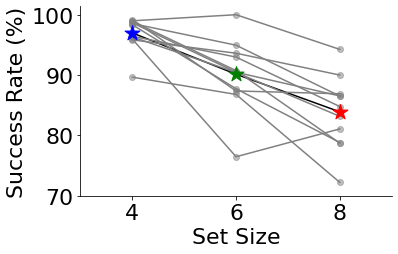

In [12]:
fig,ax = plt.subplots(figsize=(6,4))
plt.scatter([0]*len(acc4),acc4,color='gray',alpha=0.5,)
plt.scatter([0],np.mean(acc4),color='blue',marker='*',s=250)
plt.scatter([1]*len(acc6),acc6,color='gray',alpha=0.5)
plt.scatter([1],np.mean(acc6),color='green',marker='*',s=250)
plt.scatter([2]*len(acc8),acc8,color='gray',alpha=0.5)
plt.scatter([2],np.mean(acc8),color='red',marker='*',s=250)
plt.plot([0,1,2],[np.mean(acc4),np.mean(acc6),np.mean(acc8)],color='k',zorder=-1)
for i in range(len(c4)):
    plt.plot([0,1,2],[acc4[i],acc6[i],acc8[i]],color='gray',zorder=-1)
plt.xlabel('Set Size')
plt.ylabel('Success Rate (%)')
plt.xticks([0,1,2],[4,6,8])
plt.xlim(-0.5,2.5)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.yticks([0.7,0.8,0.9,1.0],[70,80,90,100])
plt.tight_layout()
plt.savefig('./acc.svg',dpi=200)
plt.show()

In [16]:
import numpy as np
import pandas as pd
import pingouin as pg

# ---- Step 1: Mean accuracy per subject ----
mean_c4 = [np.nanmean(acc) for acc in c4]
mean_c6 = [np.nanmean(acc) for acc in c6]
mean_c8 = [np.nanmean(acc) for acc in c8]

data = pd.DataFrame({
    'subject': np.arange(len(mean_c4)),
    'c4': mean_c4,
    'c6': mean_c6,
    'c8': mean_c8
})

# Long format
df_long = data.melt(id_vars='subject',
                    value_vars=['c4', 'c6', 'c8'],
                    var_name='setsize', value_name='accuracy')
df_long['setsize'] = df_long['setsize'].str.extract('(\d+)').astype(int)

# ---- Step 2: Observed F-statistic ----
aov_obs = pg.rm_anova(dv='accuracy', within='setsize', subject='subject',
                      data=df_long, detailed=True)
F_obs = aov_obs.loc[0, 'F']

# ---- Step 3: Permutation procedure ----
n_perms = 10000
F_perm = np.zeros(n_perms)

for i in range(n_perms):
    df_perm = df_long.copy()
    # Shuffle set size labels within each subject
    for s in df_perm['subject'].unique():
        mask = df_perm['subject'] == s
        df_perm.loc[mask, 'setsize'] = np.random.permutation(df_perm.loc[mask, 'setsize'].values)
    # Compute F-statistic for permuted data
    F_perm[i] = pg.rm_anova(dv='accuracy', within='setsize', subject='subject',
                            data=df_perm, detailed=True).loc[0, 'F']

# ---- Step 4: p-value ----
p_value = np.mean(F_perm >= F_obs)

print(f"Observed F = {F_obs:.3f}")
print(f"Permutation p-value = {p_value:.10f}")

Observed F = 33.265
Permutation p-value = 0.0000000000


In [26]:
1/10000

0.0001

Deterministic LMedS slope: 0.06255664304823194
Deterministic LMedS intercept: 1.1682668075372213
Median squared residual: 0.020154715328829648
R^2 (standard): 0.07285112087403156
Slope 95% CI (jackknife): (-0.07136246971818455, 0.19647575581464843)
Intercept 95% CI (jackknife): (0.32721874527564265, 2.0093148697988)


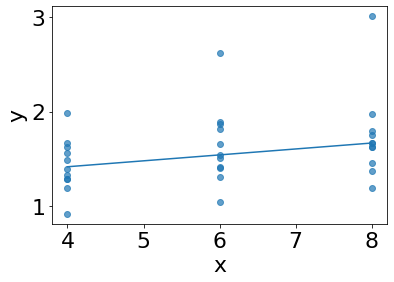

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import t as student_t

# build data
x = np.array([4]*len(m4) + [6]*len(m6) + [8]*len(m8), dtype=float)
y = np.array(m4 + m6 + m8, dtype=float)

def lmeds_line_fit_deterministic(x, y):
    n = len(x)
    best = None  # (med_sq, tie1, tie2, slope, intercept)

    for i in range(n - 1):
        for j in range(i + 1, n):
            if x[j] == x[i]:
                continue  # can't define slope from equal x

            a = (y[j] - y[i]) / (x[j] - x[i])
            b = y[i] - a * x[i]

            r = y - (a * x + b)
            r2 = r**2
            med_sq = np.median(r2)

            # deterministic tie-breakers (smaller is better)
            tie1 = np.median(np.abs(r))   # median absolute residual
            tie2 = np.sum(r2)             # SSE

            cand = (med_sq, tie1, tie2, a, b)
            if (best is None) or (cand < best):
                best = cand

    if best is None:
        raise ValueError("Could not fit: need at least two points with different x values.")
    med_sq, tie1, tie2, slope, intercept = best
    return slope, intercept, med_sq

def r2_standard(y, y_pred):
    ss_res = np.sum((y - y_pred)**2)
    ss_tot = np.sum((y - np.mean(y))**2)
    return 1 - ss_res/ss_tot

# --- Fit on full data (deterministic LMedS) ---
slope, intercept, med_sq = lmeds_line_fit_deterministic(x, y)
y_pred = slope * x + intercept
r2 = r2_standard(y, y_pred)

print("Deterministic LMedS slope:", slope)
print("Deterministic LMedS intercept:", intercept)
print("Median squared residual:", med_sq)
print("R^2 (standard):", r2)

# --- Deterministic jackknife CI (leave-one-out refits) ---
n = len(x)
slopes = []
intercepts = []

for k in range(n):
    mask = np.ones(n, dtype=bool)
    mask[k] = False
    a_k, b_k, _ = lmeds_line_fit_deterministic(x[mask], y[mask])
    slopes.append(a_k)
    intercepts.append(b_k)

slopes = np.array(slopes)
intercepts = np.array(intercepts)

# jackknife SE
s_bar = slopes.mean()
b_bar = intercepts.mean()
se_s = np.sqrt((n - 1) / n * np.sum((slopes - s_bar)**2))
se_b = np.sqrt((n - 1) / n * np.sum((intercepts - b_bar)**2))

alpha = 0.05
tcrit = student_t.ppf(1 - alpha/2, df=n-1)

s_ci = (slope - tcrit*se_s, slope + tcrit*se_s)
b_ci = (intercept - tcrit*se_b, intercept + tcrit*se_b)

print(f"Slope 95% CI (jackknife): {s_ci}")
print(f"Intercept 95% CI (jackknife): {b_ci}")

# --- Plot ---
x_grid = np.linspace(x.min(), x.max(), 200)
plt.scatter(x, y, alpha=0.7, label="Data")
plt.plot(x_grid, slope*x_grid + intercept, label="Deterministic LMedS fit")
plt.xlabel("x")
plt.ylabel("y")
#plt.legend()
plt.show()

In [18]:
cIN  = []
cOUT = []

cINall  = []
cOUTall = []

capacity = []

rIN  = []
rOUT = []

rINall  = []
rOUTall = []

for s in np.unique(subj):
    mask  = np.where(subj==s)[0]
    inS   = np.concatenate(info[mask],axis=0)[:,3]
    lenS  = np.concatenate(info[mask],axis=0)[:,0]
    rS    = np.concatenate(info[mask],axis=0)[:,-1]
    corrS = np.concatenate(info[mask],axis=0)[:,1]
    
    rIN.append(rS[['51' in str(ini) for ini in inS]])
    rOUT.append(rS[['52' in str(ini) for ini in inS]])
    
    capacity.append(lenS)
    cIN.append(corrS[['1' in str(ini) for ini in inS]])
    cOUT.append(corrS[['2' in str(ini) for ini in inS]])
   
    
    cINall.extend(corrS[['1' in str(ini) for ini in inS]])
    cOUTall.extend(corrS[['2' in str(ini) for ini in inS]])
    
    rINall.extend(rS[['51' in str(ini) for ini in inS]])
    rOUTall.extend(rS[['52' in str(ini) for ini in inS]])
    
cIN  = [np.mean(c) for c in cIN]
cOUT = [np.mean(c) for c in cOUT]

In [19]:
print(np.mean(cIN),np.std(cIN))
print(np.mean(cOUT),np.std(cOUT))

0.9240732955653509 0.053054746475033485
0.9140940571683088 0.04014897171954018


In [30]:
import numpy as np

rINall  = np.array(rINall, dtype=float)
rOUTall = np.array(rOUTall, dtype=float)

# Observed difference (IN - OUT)
obs_diff = np.mean(rINall) - np.mean(rOUTall)

# Permutation test
n_perm   = 50000
combined = np.concatenate([rINall, rOUTall])
n_in     = len(rINall)

perm_diffs = np.zeros(n_perm)

for i in range(n_perm):
    np.random.shuffle(combined)
    perm_in  = combined[:n_in]
    perm_out = combined[n_in:]
    perm_diffs[i] = np.mean(perm_in) - np.mean(perm_out)

# One-tailed p-value (testing rINall < rOUTall)
p_value = np.mean(perm_diffs <= obs_diff)

print("Observed difference (IN - OUT):", obs_diff)
print("Permutation-test p-value:", p_value)

Observed difference (IN - OUT): -0.1312404770970259
Permutation-test p-value: 6e-05


In [25]:
print(np.mean(rINall),np.std(rINall))
print(np.mean(rOUTall),np.std(rOUTall))

1.4757941805347459 0.7241448278464099
1.6070346576317718 0.8802701747148037


In [27]:
import numpy as np

# Convert to arrays of subject-level medians
sub_medians_IN  = np.array([np.median(x) for x in rIN],  dtype=float)
sub_medians_OUT = np.array([np.median(x) for x in rOUT], dtype=float)

# Observed paired difference (IN - OUT)
obs_diff = np.mean(sub_medians_IN - sub_medians_OUT)

# Permutation test
n_perm = 10000
perm_diffs = np.zeros(n_perm)

paired_diffs = sub_medians_IN - sub_medians_OUT
n_subj = len(paired_diffs)

for i in range(n_perm):
    # For each subject, randomly flip the sign of the difference
    flip = np.random.rand(n_subj) < 0.5
    perm_diffs[i] = np.mean(paired_diffs * np.where(flip, -1, 1))

# One-tailed p-value: testing IN < OUT  →  difference < 0
p_value = np.mean(perm_diffs <= obs_diff)

print("Observed difference (IN - OUT):", obs_diff)
print("Permutation-test p-value:", p_value)

Observed difference (IN - OUT): -0.15367170854048318
Permutation-test p-value: 0.1269


In [29]:
print(np.mean([np.mean(rINi) for rINi in rIN]), np.std([np.mean(rINi) for rINi in rIN]))
print(np.mean([np.mean(rOUTi) for rOUTi in rOUT]), np.std([np.mean(rOUTi) for rOUTi in rOUT]))

1.4879838269773773 0.2959689568959065
1.6521973894527682 0.4677535812649867


In [31]:
import numpy as np
import pandas as pd

def compute_cowan_k(subj, info, setsize_col=0, acc_col=1, inout_col=3):
    """
    Compute Cowan's K per subject and set size.
    Assumes:
      - info[i] is an array of trials for some block(s): columns include set size, accuracy, in/out code.
      - Accuracy is 1=correct, 0=incorrect.
      - in/out code has '1' in its string for IN trials, '2' for OUT trials (per your snippet).
    """
    rows = []

    for s_idx, s in enumerate(np.unique(subj)):
        mask = np.where(subj == s)[0]
        # Concatenate all trials for this subject across their blocks
        block = np.concatenate(info[mask], axis=0)

        N = block[:, setsize_col]                # set size per trial
        acc = block[:, acc_col].astype(float)    # correctness 0/1
        ino = block[:, inout_col]                # IN/OUT indicator (strings like '1...' or '2...')

        in_mask  = np.array(['1' in str(z) for z in ino])
        out_mask = np.array(['2' in str(z) for z in ino])

        for n in np.unique(N):
            nmask = (N == n)

            # Hit rate (IN trials at set size n)
            in_trials  = nmask & in_mask
            H = np.nan if in_trials.sum() == 0 else acc[in_trials].mean()

            # Correct rejection rate (OUT trials at set size n)
            out_trials = nmask & out_mask
            CR = np.nan if out_trials.sum() == 0 else acc[out_trials].mean()

            # Cowan's K
            K = np.nan if (np.isnan(H) or np.isnan(CR)) else n * (H + CR - 1)

            rows.append({
                'subject': s_idx,
                'setsize': int(n),
                'hits_H': H,
                'cr_CR': CR,
                'K': K,
                'n_IN_trials': int(in_trials.sum()),
                'n_OUT_trials': int(out_trials.sum())
            })

    df = pd.DataFrame(rows).sort_values(['subject', 'setsize']).reset_index(drop=True)

    # Wide convenience views
    K_wide = df.pivot(index='subject', columns='setsize', values='K')
    H_wide = df.pivot(index='subject', columns='setsize', values='hits_H')
    CR_wide = df.pivot(index='subject', columns='setsize', values='cr_CR')

    # Group summaries
    group_summary = (df
        .groupby('setsize')['K']
        .agg(mean='mean', sd='std', n='count')
        .assign(sem=lambda x: x['sd'] / np.sqrt(x['n']))
        .reset_index()
    )

    # Capacity per subject:
    # - at the largest set size (often reported)
    largest_N = int(df['setsize'].max())
    cap_at_largest = df[df['setsize'] == largest_N].set_index('subject')['K']

    # - or the maximum K across set sizes (sometimes used as a subject’s capacity estimate)
    cap_max = df.groupby('subject')['K'].max()

    return df, K_wide, H_wide, CR_wide, group_summary, cap_at_largest, cap_max

# ----- Run it -----
df_K, K_wide, H_wide, CR_wide, summary, cap_largest, cap_max = compute_cowan_k(subj, info)

print("Per-subject, per-set-size K:")
print(df_K)

print("\nGroup summary (mean K by set size):")
print(summary)

print("\nCapacity per subject at largest set size:")
print(cap_largest)

print("\nCapacity per subject (max across set sizes):")
print(cap_max)

Per-subject, per-set-size K:
    subject  setsize    hits_H     cr_CR         K  n_IN_trials  n_OUT_trials
0         0        4  0.974359  0.952941  3.709201           78            85
1         0        6  0.898305  0.910714  4.854116           59            56
2         0        8  0.900000  0.781818  5.454545           40            55
3         1        4  0.976190  0.952381  3.714286           42            42
4         1        6  0.935484  0.923077  5.151365           31            26
5         1        8  0.772727  0.916667  5.515152           22            24
6         2        4  1.000000  0.980392  3.921569           41            51
7         2        6  0.933333  0.875000  4.850000           30            24
8         2        8  0.840000  0.727273  4.538182           25            22
9         3        4  1.000000  0.983333  3.933333           39            60
10        3        6  1.000000  1.000000  6.000000           45            55
11        3        8  0.925000  0.9

In [32]:
print(np.mean(cap_largest))

5.519419834122925


In [33]:
rC  = []
rNC = []

rCall  = []
rNCall = []

for s in np.unique(subj):
    mask  = np.where(subj==s)[0]
    rS    = np.concatenate(info[mask],axis=0)[:,4]
    inS   = np.concatenate(info[mask],axis=0)[:,3]
    lenS  = np.concatenate(info[mask],axis=0)[:,0]
    corrS = np.concatenate(info[mask],axis=0)[:,1]
    
    capacity.append(lenS)
    rC.append(np.mean(rS[['5' in str(ini) for ini in inS]]))
    rNC.append(np.mean(rS[['5' not in str(ini) for ini in inS]]))
   
    
    rCall.extend(rS[['5' in str(ini) for ini in inS]])
    rNCall.extend(rS[['5' not in str(ini) for ini in inS]])

In [34]:
print(np.nanmean(rC),np.nanstd(rC))
print(np.nanmean(rNC),np.nanstd(rNC))

1.5634803644676267 0.3361819870315502
1.8937755119784798 0.5678458371373255


In [35]:
# 1) Subject-wise means (keeps the repeated-measures structure)
mean_rC   = []
mean_rNC  = []
kept_subj = []

for i, (x, y) in enumerate(zip(rC, rNC)):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    if x.size == 0 or y.size == 0:   # skip subjects with no data in a condition
        continue
    mean_rC.append(np.mean(x))
    mean_rNC.append(np.mean(y))
    kept_subj.append(i)

mean_rC  = np.asarray(mean_rC)
mean_rNC = np.asarray(mean_rNC)

# 2) Observed paired t-statistic
d  = mean_rC - mean_rNC                         # subject-wise differences
n  = d.size
sd = d.std(ddof=1)
t_obs = d.mean() / (sd / np.sqrt(n))
df = n - 1
dz = d.mean() / sd                              # Cohen's dz for paired designs

# 3) Permutation test (paired): random sign-flip of each subject's difference
rng    = np.random.default_rng(42)               
n_perm = 10000
t_perm = np.empty(n_perm)

for i in range(n_perm):
    signs = rng.choice([-1, 1], size=n, replace=True)
    d_perm = d * signs
    t_perm[i] = d_perm.mean() / (d_perm.std(ddof=1) / np.sqrt(n))

# 4) p-values
p_two   = np.nanmean(np.abs(t_perm) >= np.abs(t_obs))  # two-sided
p_right = np.nanmean(t_perm >= t_obs)                  # H1: rC > rNC
p_left  = np.nanmean(t_perm <= t_obs)                  # H1: rC < rNC

print(f"Paired permutation t-test (subject means):")
print(f"t({df}) = {t_obs:.3f}, p_two = {p_two:.4f}, p_right = {p_right:.4f}, p_left = {p_left:.4f}, dz = {dz:.3f}")
print(f"Subjects kept: {n} (skipped {len(rC)-n} with empty cells)")

Paired permutation t-test (subject means):
t(10) = -3.319, p_two = 0.0020, p_right = 0.9994, p_left = 0.0010, dz = -1.001
Subjects kept: 11 (skipped 0 with empty cells)
